# 06 — Flow Matching

Continuous Normalizing Flow with Optimal Transport — modern alternative to diffusion.

**Library:** torchcfm

**Architecture:** Small UNet backbone

**Training:** MSE loss between predicted and target velocity field

**Reference:** atong01/conditional-flow-matching mnist_example.ipynb

## Setup

In [10]:
!pip install torchxrayvision torchcfm torchdiffeq -q
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

from torchdiffeq import odeint
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [11]:
# hyperparameters
IMG_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 32
LR = 1e-4
N_EPOCHS = 50
N_GENERATE = 100

In [12]:
# paths
# DATA_DIR = Path("../data")  # for local use
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/06_flow_matching")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [13]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [14]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1]
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


## Model Architecture

Small UNet that predicts velocity field v(x, t).

In [15]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal time embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [16]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        # use min(8, ch) groups to handle small channel counts (like 1)
        self.block1 = nn.Sequential(
            nn.GroupNorm(min(8, in_ch), in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.residual_conv(x)

In [17]:
class SimpleUNet(nn.Module):
    """Small UNet for velocity field prediction."""
    def __init__(self, in_ch=1, base_ch=64, time_emb_dim=128):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        
        # encoder
        self.enc1 = ResBlock(in_ch, base_ch, time_emb_dim)
        self.enc2 = ResBlock(base_ch, base_ch * 2, time_emb_dim)
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, 2, 1)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, 2, 1)
        self.down3 = nn.Conv2d(base_ch * 4, base_ch * 4, 4, 2, 1)
        
        # bottleneck
        self.mid = ResBlock(base_ch * 4, base_ch * 4, time_emb_dim)
        
        # decoder
        self.up3 = nn.ConvTranspose2d(base_ch * 4, base_ch * 4, 4, 2, 1)
        self.dec3 = ResBlock(base_ch * 8, base_ch * 2, time_emb_dim)
        
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch * 2, 4, 2, 1)
        self.dec2 = ResBlock(base_ch * 4, base_ch, time_emb_dim)
        
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, 2, 1)
        self.dec1 = ResBlock(base_ch * 2, base_ch, time_emb_dim)
        
        self.out = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        
        # encoder
        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.down1(e1), t_emb)
        e3 = self.enc3(self.down2(e2), t_emb)
        
        # bottleneck
        m = self.mid(self.down3(e3), t_emb)
        
        # decoder with skip connections
        d3 = self.dec3(torch.cat([self.up3(m), e3], dim=1), t_emb)
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1), t_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1), t_emb)
        
        return self.out(d1)

In [18]:
model = SimpleUNet(in_ch=CHANNELS, base_ch=64).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 6,403,907


In [19]:
# flow matcher from torchcfm
flow_matcher = ConditionalFlowMatcher(sigma=0.0)

## Training

In [20]:
optimizer = optim.Adam(model.parameters(), lr=LR)

In [21]:
train_losses = []

print("Starting training...")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for batch_idx, x1 in enumerate(pbar):
        x1 = x1.to(device)  # target (real images)
        x0 = torch.randn_like(x1)  # source (noise)
        
        # sample time and compute flow matching target
        t, xt, ut = flow_matcher.sample_location_and_conditional_flow(x0, x1)
        t = t.to(device)
        xt = xt.to(device)
        ut = ut.to(device)
        
        # predict velocity field
        vt = model(xt, t)
        
        # MSE loss between predicted and target velocity
        loss = F.mse_loss(vt, ut)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f}")
    
    if (epoch + 1) % 10 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training...


Epoch 1/50: 100%|██████████| 121/121 [00:13<00:00,  8.77it/s, loss=0.1647]


Epoch 1: loss=0.3193


Epoch 2/50: 100%|██████████| 121/121 [00:12<00:00,  9.57it/s, loss=0.1915]


Epoch 2: loss=0.1861


...

Epoch 48: loss=0.1186


Epoch 49/50: 100%|██████████| 121/121 [00:14<00:00,  8.26it/s, loss=0.1606]


Epoch 49: loss=0.1146


Epoch 50/50: 100%|██████████| 121/121 [00:14<00:00,  8.26it/s, loss=0.0943]


Epoch 50: loss=0.1175
Saved checkpoint: outputs/06_flow_matching/checkpoints/checkpoint_epoch_50.pt
Training complete!


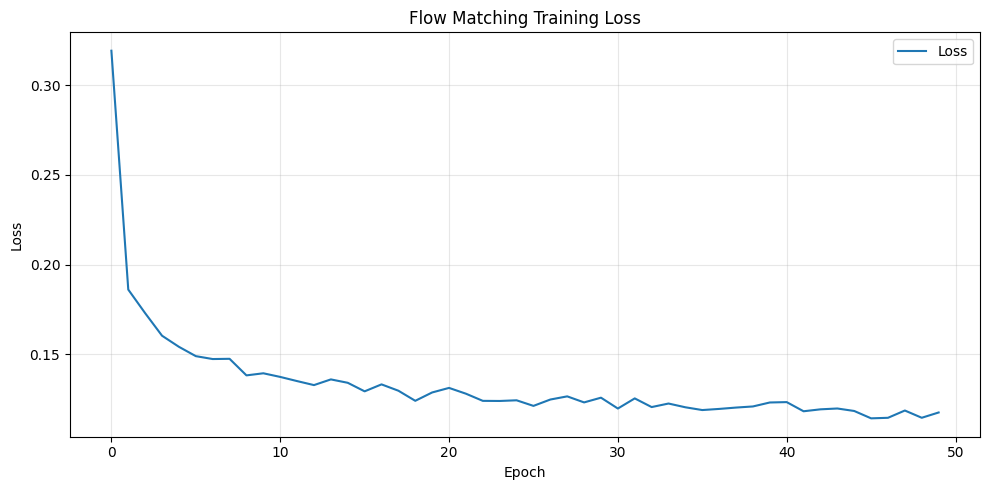

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Flow Matching Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

## Generate 100 Images

In [23]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

model.eval()
generated_paths = []

In [24]:
class ODEFunc(nn.Module):
    """Wrapper for ODE solver."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, t, x):
        t_batch = t.expand(x.shape[0])
        return self.model(x, t_batch)

In [25]:
ode_func = ODEFunc(model)

# generate in batches
batch_size = 10
n_batches = N_GENERATE // batch_size

for batch_idx in tqdm(range(n_batches), desc="Generating"):
    # start from noise
    torch.manual_seed(SEED + batch_idx)
    x0 = torch.randn(batch_size, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    
    # integrate ODE from t=0 to t=1 (10 steps, per MOTFM paper recommendation)
    with torch.no_grad():
        t_span = torch.tensor([0.0, 1.0], device=device)
        x1 = odeint(ode_func, x0, t_span, method='euler', options={'step_size': 0.1})[-1]
    
    for i, img_tensor in enumerate(x1):
        idx = batch_idx * batch_size + i
        img = img_tensor.squeeze().cpu().numpy()
        img = ((img + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{idx:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")

Generating: 100%|██████████| 10/10 [00:01<00:00,  6.40it/s]

Generated 100 images


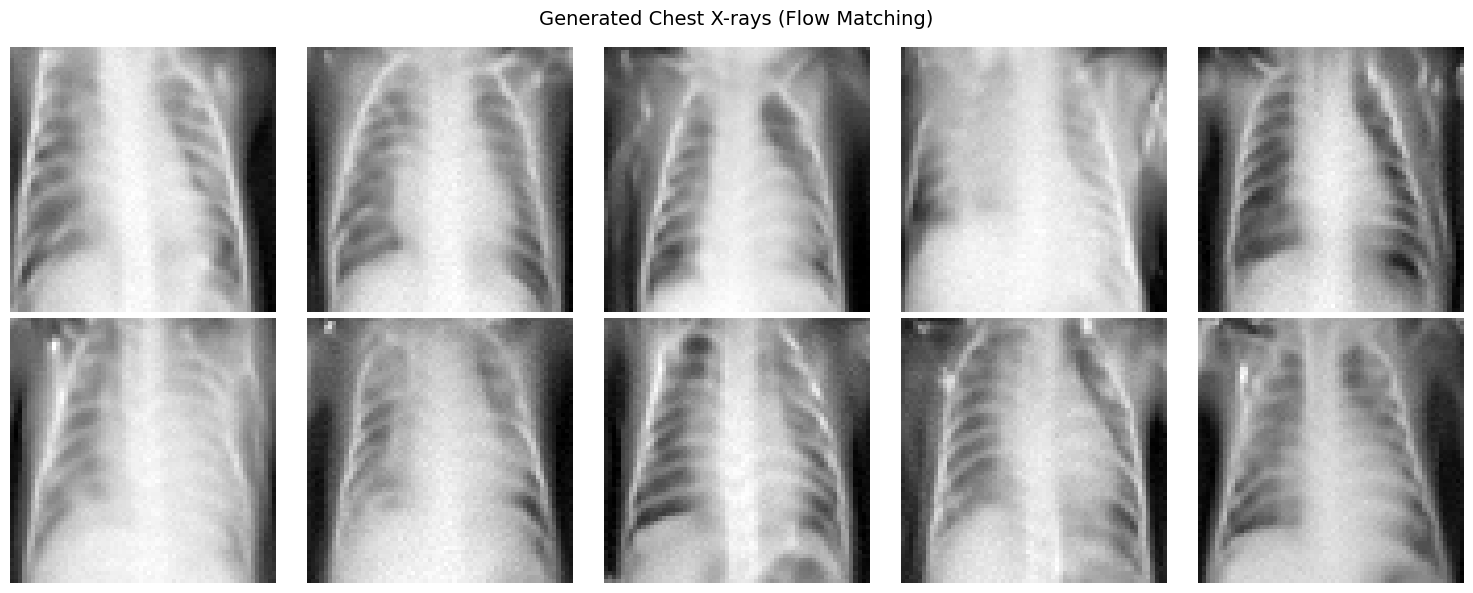

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (Flow Matching)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

In [27]:
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [28]:
def load_and_preprocess_for_xrv(img_path):
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    if len(real_features) < 2 or len(fake_features) < 2:
        return None
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    eps = 1e-6
    sigma_real += np.eye(sigma_real.shape[0]) * eps
    sigma_fake += np.eye(sigma_fake.shape[0]) * eps
    diff = mu_real - mu_fake
    try:
        covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        if not np.isfinite(covmean).all():
            return None
        fid = float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))
        return fid if np.isfinite(fid) else None
    except Exception:
        return None

In [29]:
real_paths = sorted([p for p in REAL_DIR.iterdir() if p.suffix == '.png'])[:N_GENERATE]

print("Extracting features from real images...")
real_features = extract_features(real_paths)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  6.54it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00, 10.00it/s]



Domain-adapted FID (DenseNet121): 40.35


## Evaluate — Label + TSTR (torchxrayvision)

In [30]:
def label_images(image_paths, batch_size=32):
    all_predictions = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    return np.concatenate(all_predictions, axis=0)

In [31]:
predictions = label_images(generated_paths)
pathology_names = xrv_model.pathologies

pneumonia_idx = next(
    (i for i, name in enumerate(pathology_names) if 'lung opacity' in name.lower()),
    None
)
print(f"Using pathology index {pneumonia_idx}: {pathology_names[pneumonia_idx]}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  6.59it/s]

Using pathology index 16: Lung Opacity


In [32]:
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.891
  Classified as pneumonia (>0.5): 100/100 (100.0%)


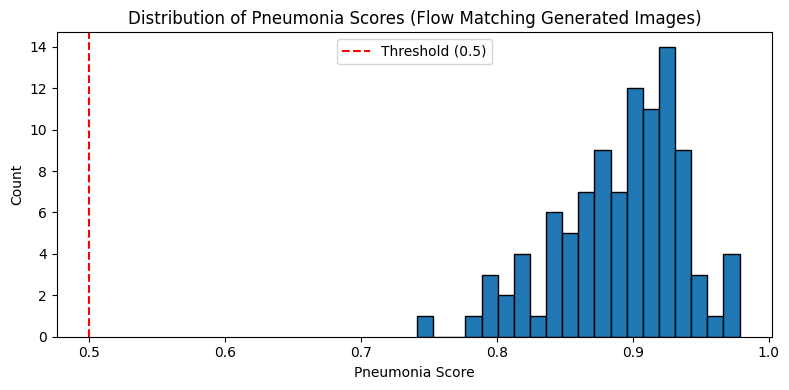

In [33]:
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (Flow Matching Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [34]:
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

Saved labels to outputs/06_flow_matching/labels.csv


In [35]:
metrics = {
    'model': 'flow_matching',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'final_loss': train_losses[-1] if train_losses else None,
    'seed': SEED
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/06_flow_matching/metrics.json
{
  "model": "flow_matching",
  "n_generated": 100,
  "fid_domain_adapted": 40.353098801156754,
  "tstr_accuracy": 100.0,
  "mean_pneumonia_score": 0.8909754753112793,
  "epochs": 50,
  "batch_size": 32,
  "learning_rate": 0.0001,
  "final_loss": 0.11754730651693895,
  "seed": 42
}


## Results

In [36]:
print("="*50)
print("FLOW MATCHING RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final loss: {train_losses[-1]:.4f}")
print("="*50)

FLOW MATCHING RESULTS
Images generated: 100
Training epochs: 50
Domain-adapted FID: 40.35
Proxy TSTR accuracy: 100.0%
Mean pneumonia score: 0.891
Final loss: 0.1175
